In [1]:
import pandas as pd
import pandas as pd
import io
df = pd.read_csv('Salary_Data.csv')

In [2]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
import matplotlib.pyplot as plt
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())#numerical
#categorical
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])

In [6]:
#data type conversion
df['Age'] = df['Age'].astype(int)

In [7]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]

Text(0.5, 1.0, 'Age Distribution')

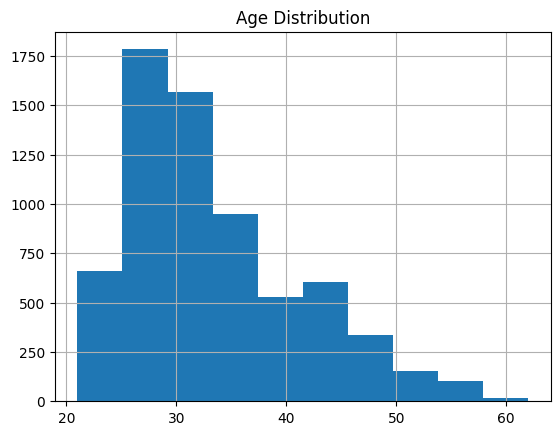

In [8]:

df['Age'].hist()
plt.title('Age Distribution')

Text(0.5, 1.0, 'Experience vs Salary')

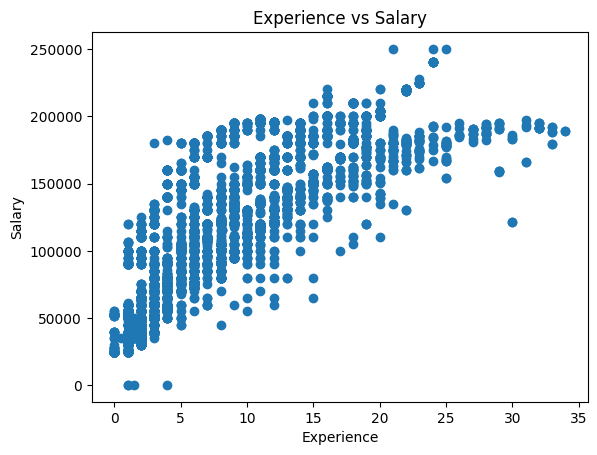

In [9]:
plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')

Text(0.5, 1.0, 'Age vs Salary')

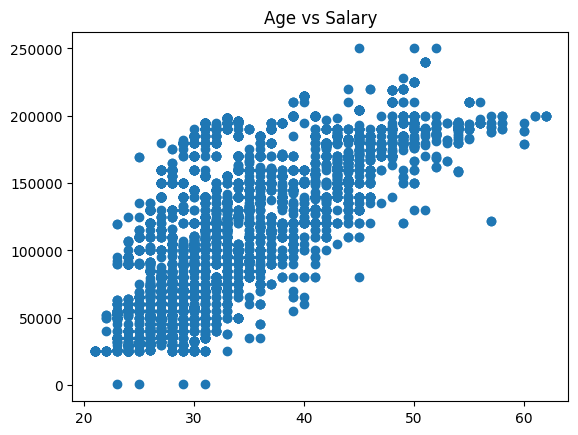

In [10]:

plt.scatter(df['Age'], df['Salary'])
plt.title('Age vs Salary')

In [11]:
df.groupby('Education Level')['Salary'].mean()

Education Level
Bachelor's           124767.658730
Bachelor's Degree     85234.548396
High School           36706.694196
Master's             157604.166667
Master's Degree      125069.136659
PhD                  165684.828947
phD                  120000.000000
Name: Salary, dtype: float64

In [12]:
df['Gender'].value_counts()

Gender
Male      3676
Female    3014
Other       14
Name: count, dtype: int64

In [13]:
df['Job Title'].value_counts()

Job Title
Software Engineer                520
Data Scientist                   453
Software Engineer Manager        376
Data Analyst                     363
Senior Project Engineer          318
                                ... 
Junior Operations Coordinator      1
Junior Financial Advisor           1
Developer                          1
Social M                           1
Social Media Man                   1
Name: count, Length: 193, dtype: int64

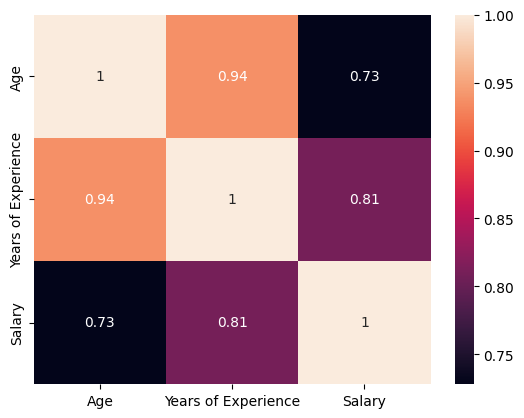

In [15]:
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

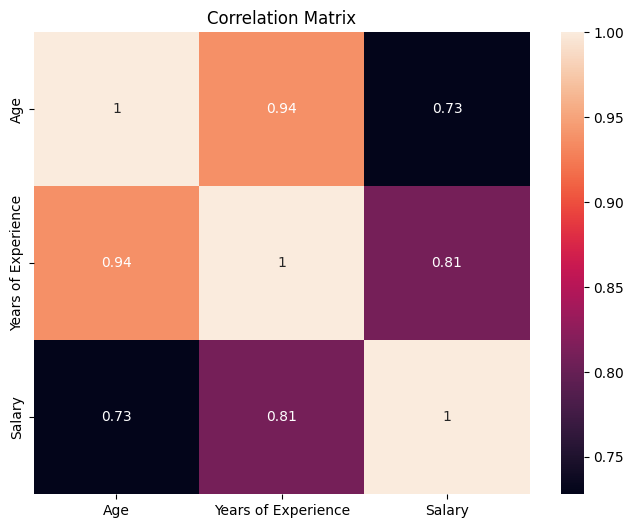

In [16]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

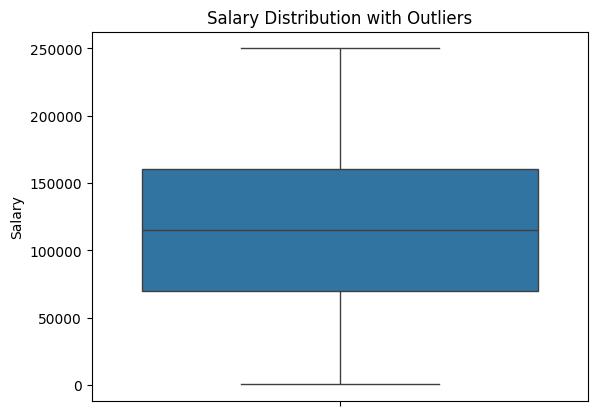

In [17]:
sns.boxplot(y='Salary', data=df)
plt.title("Salary Distribution with Outliers")
plt.show()

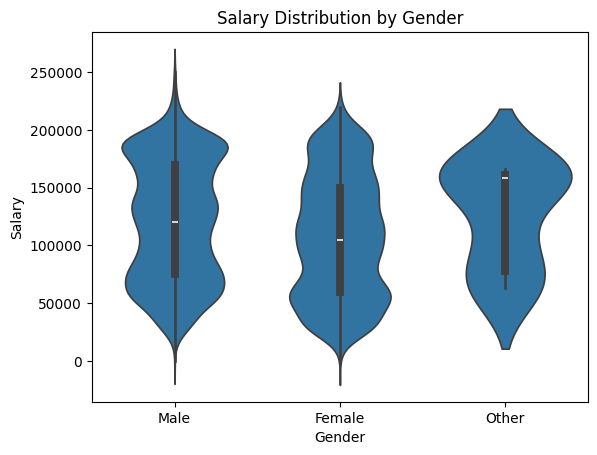

In [18]:
sns.violinplot(x='Gender', y='Salary', data=df)
plt.title("Salary Distribution by Gender")
plt.show()

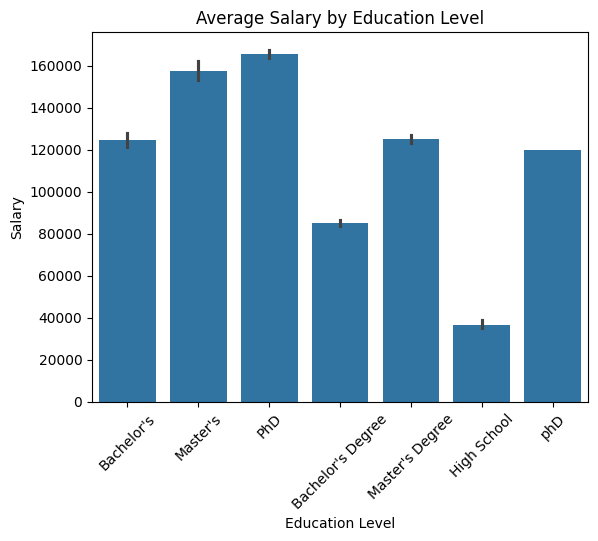

In [19]:
sns.barplot(x='Education Level', y='Salary', data=df)
plt.xticks(rotation=45)
plt.title("Average Salary by Education Level")
plt.show()

In [20]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df=df.dropna()

In [21]:
X = df[["Years_of_Experience"]]
y = df["Salary"]

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (m): 7059.847257480061
Intercept (b): 58366.54243606136


In [25]:
print("Score:", model.score(X_test, y_test))

Score: 0.6528690431769464


In [26]:
years = float(input("Enter years of experience: "))
pred = model.predict([[years]])
print("Predicted Salary:", int(pred[0]))

Predicted Salary: 86605


c:\Users\Bhakti\Desktop\Salary Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


c:\Users\Bhakti\Desktop\Salary Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


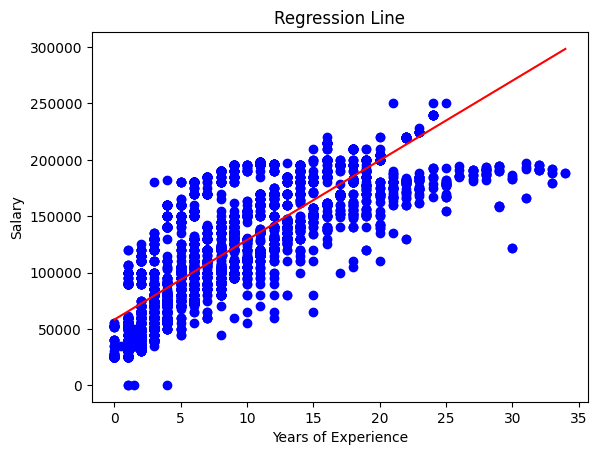

In [27]:
import matplotlib.pyplot as plt
import numpy as np
X_sorted = np.sort(X.values, axis=0)
y_pred = model.predict(X_sorted)
plt.scatter(X, y, color="blue")
plt.plot(X_sorted, y_pred, color="red")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Regression Line")

plt.show()

MAE: 24424.617724158365
MSE: 927079077.8702132
RMSE: 30447.973296595836
R² Score: 0.6528690431769464
Train R²: 0.6545848629636568
Test R²: 0.6528690431769464
Cross Validation R² Scores: [-0.4006221   0.67868759  0.67587766  0.74313193  0.77774094]
Average CV R²: 0.49496320196964094


c:\Users\Bhakti\Desktop\Salary Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


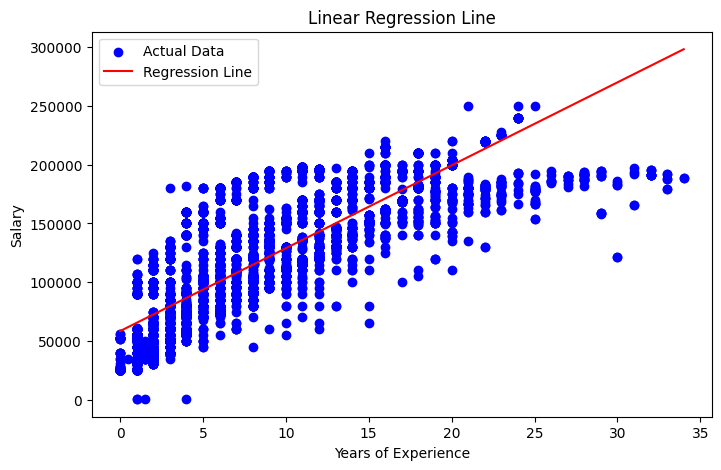

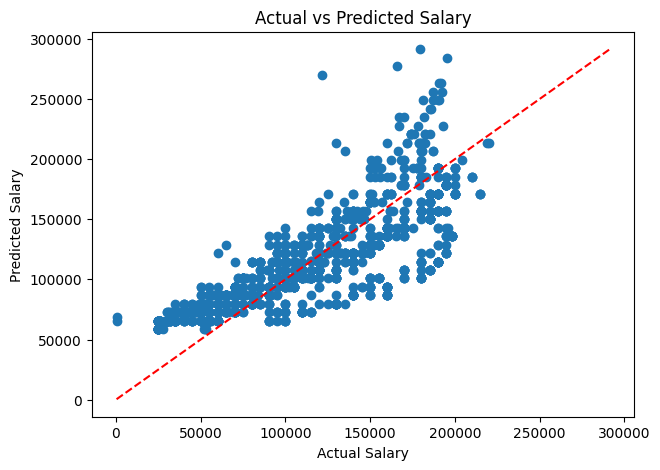

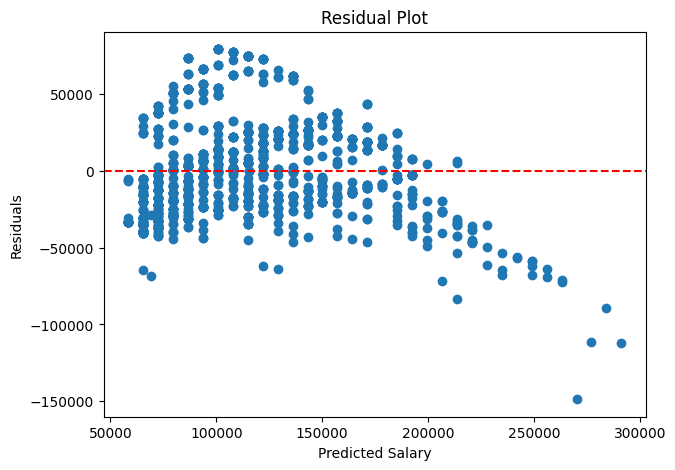

Model saved successfully!


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import joblib

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross Validation R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

# Regression line
X_sorted = np.sort(X.values, axis=0)
y_line = model.predict(X_sorted)

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X_sorted, y_line, color="red", label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Line")
plt.legend()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

joblib.dump(model, "salary_prediction_model.pkl")
print("Model saved successfully!")

In [29]:
joblib.dump(model, "salary_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!
